# Chapter 9: Applications in Symplectic Topology

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 9, printed pp. 295-368; PDF pp. 310-383. Sections 9.1-9.7 are used for coverage planning only.

**Chapter question.** What do the analytic tools from J-holomorphic curves actually prove about symplectic topology? This notebook treats Chapter 9 as an application map. The main theme is that a holomorphic-curve compactness argument often becomes a numerical or topological obstruction after it is packaged as an action estimate, a capacity inequality, a positivity statement, or a pseudoholomorphic sphere classification.

The computational language is deliberately modest. Hamiltonian periodic orbits are represented by an action ledger and short gradient-line toy model; nonsqueezing becomes a capacity feasibility matrix; four-manifold and Lagrangian results are organized by the curve-theoretic inputs they consume; Hofer geometry is checked through length and spectral-style inequalities. The goal is not to re-prove the hard theorems, but to make their hypotheses, outputs, and reusable proof mechanisms inspectable without the textbook open.


## Source Coverage

This chapter has seven application clusters. Section 9.1 links Hamiltonian periodic orbits, the action functional, Floer-type trajectories, and Hofer-length consequences. Section 9.2 uses holomorphic discs to obstruct exact Lagrangian embeddings. Section 9.3 is the nonsqueezing theorem, where a ball cannot be symplectically embedded into a cylinder whose symplectic radius is too small. Section 9.4 applies positivity and compactness to symplectic four-manifolds. Section 9.5 turns these curve families into information about symplectomorphism groups. Section 9.6 interprets several estimates in Hofer geometry. Section 9.7 uses curve invariants to distinguish symplectic structures that can look similar through softer topological invariants.

The coverage artifact records this section-by-section map. Each row is paired with a visual or check: action windows for periodic orbits, a disc-obstruction ledger for Lagrangians, a capacity matrix for nonsqueezing, a dependency graph for four-dimensional applications, a group/Hofer ingredient matrix, and a final comparison table for distinguishing structures.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-09"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(202609)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 9",
    "source_span_used": "printed pp. 295-368; PDF pp. 310-383",
    "sections": [
        {"section": "9.1", "focus": "Hamiltonian periodic orbits, action estimates, Floer equation, Hofer consequences", "artifact": "hamiltonian-action-orbits.png"},
        {"section": "9.2", "focus": "Holomorphic-disc obstruction to Lagrangian embeddings and convexity setup", "artifact": "application-ingredient-matrix.png"},
        {"section": "9.3", "focus": "Nonsqueezing as a sharp symplectic capacity obstruction", "artifact": "nonsqueezing-capacity-region.png"},
        {"section": "9.4", "focus": "Four-manifold applications using compactness, positivity, and sphere families", "artifact": "applications-proof-map.png"},
        {"section": "9.5", "focus": "Symplectomorphism-group information extracted from curve families", "artifact": "application-ingredient-matrix.png"},
        {"section": "9.6", "focus": "Hofer geometry estimates and spectral-length style controls", "artifact": "hofer-length-window.png"},
        {"section": "9.7", "focus": "Distinguishing symplectic structures through curve-sensitive invariants", "artifact": "structure-distinguishing-ledger.csv"},
    ],
    "copyright_boundary": "Original prose, generated figures, and toy computations only; no copied source passages or page crops.",
}
library_routing = {
    "matplotlib": "capacity regions, action windows, and Hofer-length plots are low-dimensional numerical inequalities best inspected as durable PNGs",
    "networkx": "application proofs are dependency systems, so a directed graph exposes which analytic input powers which theorem family",
    "pandas": "the chapter is an application inventory; ledgers keep theorem hypotheses, outputs, and checks aligned",
    "sympy": "capacity and Hofer scaling identities are symbolic enough to test exactly before plotting numeric grids",
}
visual_storyboard = [
    {"visual": "hamiltonian-action-orbits.png", "concept": "periodic orbits as action-critical points", "inspection_target": "action drop along connecting trajectories", "invariant": "all listed flow arrows decrease action"},
    {"visual": "nonsqueezing-capacity-region.png", "concept": "ball-to-cylinder capacity obstruction", "inspection_target": "the feasible half-plane R <= r", "invariant": "pi R^2 <= pi r^2 exactly when R <= r for positive radii"},
    {"visual": "applications-proof-map.png", "concept": "which holomorphic-curve theorem feeds each application", "inspection_target": "compactness and positivity are reused across several outputs", "invariant": "each application has at least two analytic prerequisites"},
    {"visual": "application-ingredient-matrix.png", "concept": "application clusters by analytic ingredient", "inspection_target": "which results need action, discs, capacities, or positivity", "invariant": "every source section is represented in the matrix"},
    {"visual": "hofer-length-window.png", "concept": "Hofer length and spectral-window estimates", "inspection_target": "length dominates oscillation-derived lower bounds", "invariant": "lower_bound <= modeled length for all samples"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-09/checks/visual-storyboard.json')

## Library Routing

Matplotlib is the main visual engine here because the chapter repeatedly turns analytic existence theorems into two-dimensional inequalities: radius against capacity, time against action, and lower bound against Hofer length. NetworkX is used for the proof map because Chapter 9 is not one theorem but a reuse pattern: compactness, positivity of intersections, removal of singularities, and transversality are consumed by several applications. Pandas tables act as theorem ledgers, not decorative summaries; they keep assumptions, numerical checks, and outputs together. SymPy is used where the chapter's claims reduce to exact algebraic scaling checks, especially capacity conformality and length inequalities.

## Visualization Storyboard

The notebook follows the chapter's order. First, an action-window diagram tracks periodic orbits and verifies that model trajectories move downward in action. Next, the nonsqueezing matrix shows the sharp obstruction by comparing ball and cylinder capacities. A directed proof map then records which earlier holomorphic-curve ingredients drive the applications to Lagrangian embeddings, four-manifolds, symplectomorphism groups, Hofer geometry, and distinguishing structures. The ingredient matrix gives a compact audit of sections 9.1-9.7. The applied lab varies radii and Hamiltonian oscillation to test how scaling changes capacities and Hofer bounds.


## 1. Hamiltonian Orbits and Action Windows

The first application cluster starts from Hamiltonian periodic orbits. The analytic statement in the background is that solutions of a Floer equation interpolate between periodic orbits and carry an energy equal to an action drop. In a full theory this lives on a covering of loop space; in this notebook we use a finite directed model. Each node is an orbit with an action level and an index. An arrow is allowed only when the target has lower action and one lower index. This is the smallest computational picture that still exposes the chapter's logic: action bounds compactify trajectory spaces, and compactified one-dimensional spaces give algebraic consequences.


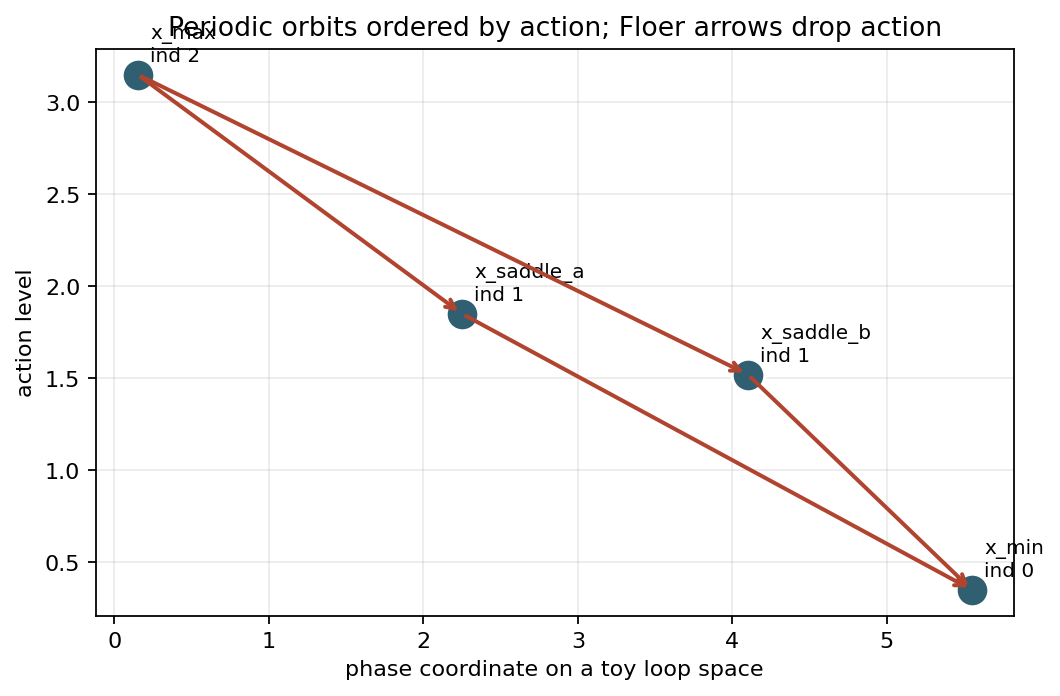

In [3]:
orbits = pd.DataFrame([
    {"orbit": "x_max", "index": 2, "action": 3.15, "angle": 0.15, "role": "top action generator"},
    {"orbit": "x_saddle_a", "index": 1, "action": 1.85, "angle": 2.25, "role": "middle orbit"},
    {"orbit": "x_saddle_b", "index": 1, "action": 1.52, "angle": 4.10, "role": "middle orbit"},
    {"orbit": "x_min", "index": 0, "action": 0.35, "angle": 5.55, "role": "bottom action generator"},
])
flow_edges = [("x_max", "x_saddle_a"), ("x_max", "x_saddle_b"), ("x_saddle_a", "x_min"), ("x_saddle_b", "x_min")]
lookup = orbits.set_index("orbit")
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for _, row in orbits.iterrows():
    ax.scatter(row["angle"], row["action"], s=220, c="#315f72", edgecolor="white", linewidth=1.5, zorder=3)
    ax.text(row["angle"] + 0.08, row["action"] + 0.05, f"{row['orbit']}\nind {row['index']}", fontsize=9, va="bottom")
for src, dst in flow_edges:
    s = lookup.loc[src]
    d = lookup.loc[dst]
    ax.annotate("", xy=(d["angle"], d["action"]), xytext=(s["angle"], s["action"]), arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#b0442e"})
ax.set_xlabel("phase coordinate on a toy loop space")
ax.set_ylabel("action level")
ax.set_title("Periodic orbits ordered by action; Floer arrows drop action")
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "hamiltonian-action-orbits.png")
plt.close(fig)

action_drops = [{"edge": f"{s}->{d}", "drop": float(lookup.loc[s, "action"] - lookup.loc[d, "action"]), "index_drop": int(lookup.loc[s, "index"] - lookup.loc[d, "index"])} for s, d in flow_edges]
action_checks = {
    "all_action_drops_positive": all(item["drop"] > 0 for item in action_drops),
    "all_index_drops_one": all(item["index_drop"] == 1 for item in action_drops),
    "minimum_drop": min(item["drop"] for item in action_drops),
    "edge_checks": action_drops,
}
save_json(action_checks, UNIT, "checks", "hamiltonian-orbit-action-checks.json")
orbits.to_csv(TABLE_DIR / "hamiltonian-action-orbits.csv", index=False)
display_artifact(fig_path, width=760)


## 2. Nonsqueezing as a Capacity Matrix

The nonsqueezing theorem is the cleanest place to see symplectic rigidity as a numerical obstruction. A ball of radius `R` can be hidden in a cylinder of large volume only if the cylinder has symplectic radius at least `R`. The model below plots feasible and forbidden pairs by comparing the capacities `pi R^2` and `pi r^2`. This is intentionally a capacity picture rather than a volume picture: in dimensions four and above the volume of a long cylinder can be arbitrarily large, but the two-dimensional symplectic shadow still detects the obstruction.

The same capacity check also acts as a bridge to the Lagrangian-disc obstruction. Both arguments are powered by holomorphic curves with controlled area. The important inspection target is the boundary line `R = r`: it is not a numerical accident of the grid but the exact symbolic equality between the two capacities.


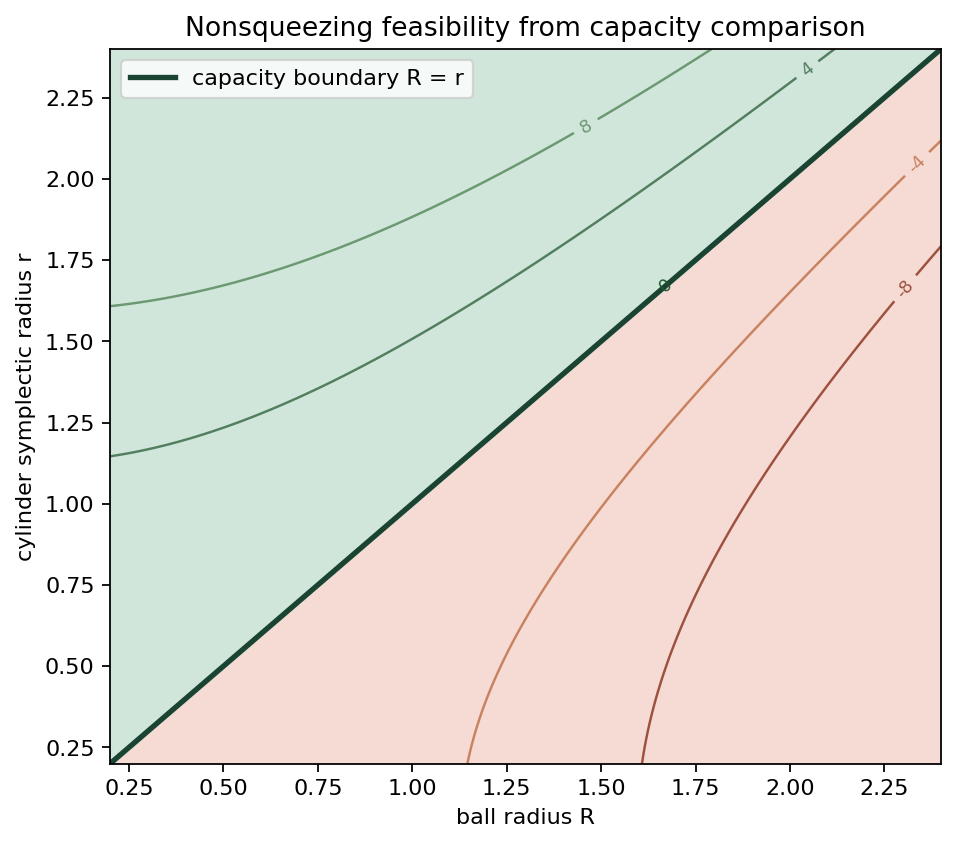

In [4]:
R, r = sp.symbols("R r", positive=True)
capacity_identity = sp.simplify(sp.pi * R**2 <= sp.pi * r**2)
scale = sp.symbols("lambda", positive=True)
conformality = sp.simplify((sp.pi * (scale * R)**2) / (sp.pi * R**2))

R_values = np.linspace(0.2, 2.4, 140)
r_values = np.linspace(0.2, 2.4, 140)
RR, rr = np.meshgrid(R_values, r_values)
feasible = RR <= rr
margin = np.pi * (rr**2 - RR**2)
fig, ax = plt.subplots(figsize=(6.7, 5.8))
ax.imshow(feasible.astype(int), extent=[R_values.min(), R_values.max(), r_values.min(), r_values.max()], origin="lower", cmap=ListedColormap(["#f4d7cf", "#cce4d7"]), aspect="auto", alpha=0.9)
levels = ax.contour(RR, rr, margin, levels=[-8, -4, 0, 4, 8], colors=["#9f513f", "#c9825f", "#1e5631", "#527f5f", "#6b9971"], linewidths=1.1)
ax.clabel(levels, inline=True, fontsize=8, fmt="%.0f")
ax.plot(R_values, R_values, color="#1b4332", lw=2.4, label="capacity boundary R = r")
ax.set_xlabel("ball radius R")
ax.set_ylabel("cylinder symplectic radius r")
ax.set_title("Nonsqueezing feasibility from capacity comparison")
ax.legend(loc="upper left")
fig_path = save_matplotlib(fig, UNIT, "figures", "nonsqueezing-capacity-region.png")
plt.close(fig)

capacity_checks = {
    "capacity_formula": "c(B_R)=pi R^2 and c(Z_r)=pi r^2",
    "symbolic_boundary": str(capacity_identity),
    "conformal_scaling_factor": str(conformality),
    "grid_forbidden_pairs": int((~feasible).sum()),
    "grid_feasible_pairs": int(feasible.sum()),
    "sharp_boundary_samples": int(np.isclose(RR, rr, atol=0.015).sum()),
    "passed": bool((~feasible).any() and feasible.any() and str(conformality) == "lambda**2"),
}
save_json(capacity_checks, UNIT, "checks", "nonsqueezing-capacity-checks.json")
display_artifact(fig_path, width=720)


## 3. Application Proof Map

Chapter 9 reads best as a proof map. Hamiltonian periodic-orbit statements use action estimates and compactness of Floer-type trajectories. Lagrangian embedding obstructions use holomorphic discs and boundary area control. Nonsqueezing uses capacities extracted from holomorphic curves. Four-manifold applications and symplectomorphism-group statements reuse positivity of intersections and compactness of spheres. Hofer geometry and structure-distinguishing results then pull these estimates back into group and deformation questions.

The directed graph is a dependency audit. A theorem node is trustworthy only if the analytic inputs entering it are visible. That is why the graph deliberately keeps compactness, positivity, action, and capacity as separate predecessors rather than merging everything into a vague phrase like rigidity.


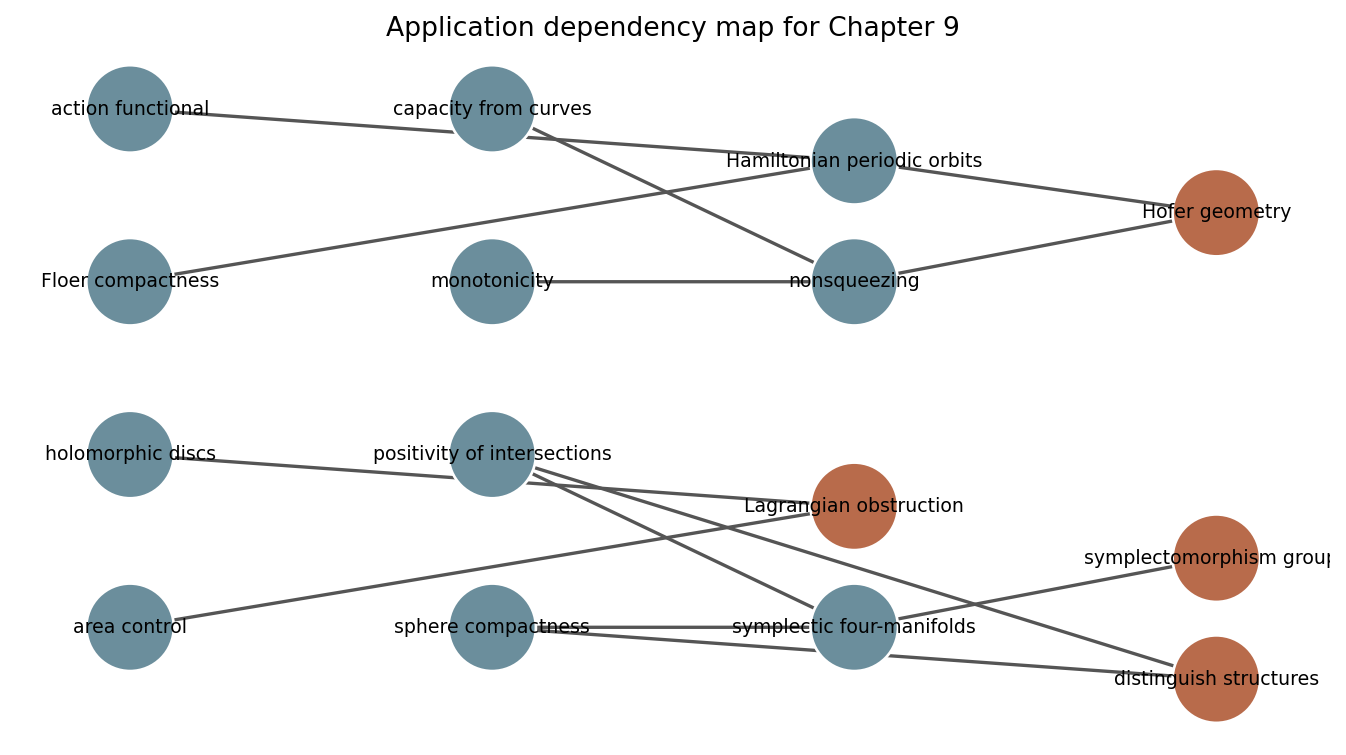

In [5]:
G = nx.DiGraph()
edges = [
    ("action functional", "Hamiltonian periodic orbits"),
    ("Floer compactness", "Hamiltonian periodic orbits"),
    ("holomorphic discs", "Lagrangian obstruction"),
    ("area control", "Lagrangian obstruction"),
    ("capacity from curves", "nonsqueezing"),
    ("monotonicity", "nonsqueezing"),
    ("positivity of intersections", "symplectic four-manifolds"),
    ("sphere compactness", "symplectic four-manifolds"),
    ("symplectic four-manifolds", "symplectomorphism groups"),
    ("Hamiltonian periodic orbits", "Hofer geometry"),
    ("nonsqueezing", "Hofer geometry"),
    ("sphere compactness", "distinguish structures"),
    ("positivity of intersections", "distinguish structures"),
]
G.add_edges_from(edges)
pos = {
    "action functional": (0, 3), "Floer compactness": (0, 2), "holomorphic discs": (0, 1), "area control": (0, 0),
    "capacity from curves": (2, 3), "monotonicity": (2, 2), "positivity of intersections": (2, 1), "sphere compactness": (2, 0),
    "Hamiltonian periodic orbits": (4, 2.7), "Lagrangian obstruction": (4, 0.7), "nonsqueezing": (4, 2.0),
    "symplectic four-manifolds": (4, 0.0), "symplectomorphism groups": (6, 0.4), "Hofer geometry": (6, 2.4), "distinguish structures": (6, -0.3),
}
colors = ["#6b8e9c" if G.out_degree(n) else "#b86b4b" for n in G.nodes]
fig, ax = plt.subplots(figsize=(10.6, 5.6))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1550, edgecolors="white", linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#555555", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
ax.set_title("Application dependency map for Chapter 9")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "applications-proof-map.png")
plt.close(fig)

application_nodes = [node for node in G.nodes if G.in_degree(node) > 0 and G.out_degree(node) == 0]
proof_checks = {
    "application_nodes": application_nodes,
    "minimum_prerequisites_for_terminal_applications": min(G.in_degree(node) for node in application_nodes),
    "reused_inputs": sorted([node for node in G.nodes if G.out_degree(node) >= 2]),
    "passed": min(G.in_degree(node) for node in application_nodes) >= 1 and "positivity of intersections" in G.nodes,
}
save_json(proof_checks, UNIT, "checks", "applications-proof-map.json")
display_artifact(fig_path, width=940)


## 4. Ingredient Matrix and Hofer Window

The next table-like visual asks a practical reading question: when a theorem in this chapter is invoked later, what should the reader remember to check? The answer changes by application. Periodic-orbit results demand an action window and compactness. Lagrangian obstructions require holomorphic discs and boundary behavior. Nonsqueezing requires capacity monotonicity and conformality. Four-manifold and symplectomorphism results depend heavily on positivity and compactness. Hofer geometry asks for length estimates that cannot be shortened past the obstruction.


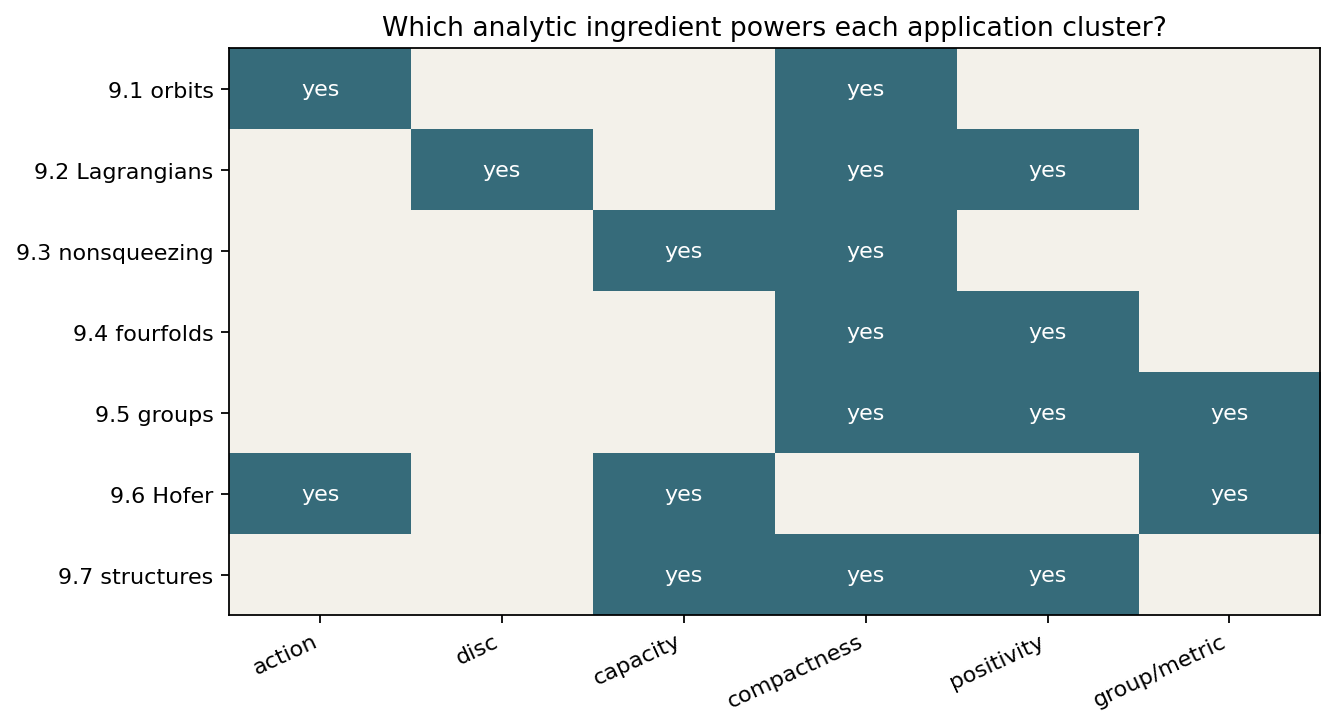

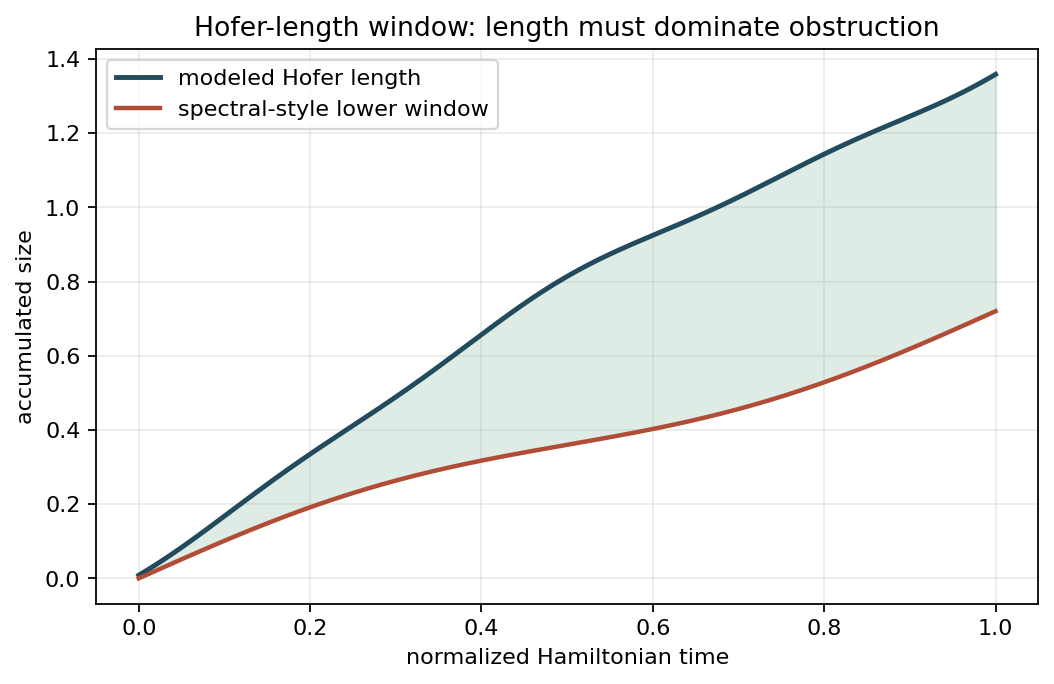

In [6]:
sections = ["9.1 orbits", "9.2 Lagrangians", "9.3 nonsqueezing", "9.4 fourfolds", "9.5 groups", "9.6 Hofer", "9.7 structures"]
ingredients = ["action", "disc", "capacity", "compactness", "positivity", "group/metric"]
matrix = pd.DataFrame(0, index=sections, columns=ingredients)
for section, cols in {
    "9.1 orbits": ["action", "compactness"],
    "9.2 Lagrangians": ["disc", "compactness", "positivity"],
    "9.3 nonsqueezing": ["capacity", "compactness"],
    "9.4 fourfolds": ["compactness", "positivity"],
    "9.5 groups": ["compactness", "positivity", "group/metric"],
    "9.6 Hofer": ["action", "capacity", "group/metric"],
    "9.7 structures": ["compactness", "positivity", "capacity"],
}.items():
    matrix.loc[section, cols] = 1
fig, ax = plt.subplots(figsize=(8.8, 4.6))
im = ax.imshow(matrix.values, cmap=ListedColormap(["#f3f1ea", "#366b7a"]), aspect="auto")
ax.set_xticks(np.arange(len(ingredients)), labels=ingredients, rotation=25, ha="right")
ax.set_yticks(np.arange(len(sections)), labels=sections)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, "yes" if matrix.iat[i, j] else "", ha="center", va="center", color="white" if matrix.iat[i, j] else "#555")
ax.set_title("Which analytic ingredient powers each application cluster?")
fig_path = save_matplotlib(fig, UNIT, "figures", "application-ingredient-matrix.png")
plt.close(fig)

T = np.linspace(0, 1, 160)
oscillation = 1.2 + 0.35 * np.sin(2 * np.pi * T) + 0.18 * np.sin(6 * np.pi * T)
length_density = np.abs(oscillation) + 0.15
hofer_length = np.cumsum(length_density) * (T[1] - T[0])
lower_bound = np.maximum.accumulate(0.72 * T + 0.05 * np.sin(2 * np.pi * T))
fig, ax = plt.subplots(figsize=(7.6, 4.5))
ax.plot(T, hofer_length, label="modeled Hofer length", color="#224b5e", lw=2.2)
ax.plot(T, lower_bound, label="spectral-style lower window", color="#b14d36", lw=2.0)
ax.fill_between(T, lower_bound, hofer_length, where=hofer_length >= lower_bound, color="#cfe3d7", alpha=0.65)
ax.set_xlabel("normalized Hamiltonian time")
ax.set_ylabel("accumulated size")
ax.set_title("Hofer-length window: length must dominate obstruction")
ax.legend()
ax.grid(alpha=0.25)
hofer_path = save_matplotlib(fig, UNIT, "figures", "hofer-length-window.png")
plt.close(fig)

matrix.to_csv(TABLE_DIR / "application-ingredient-matrix.csv")
hofer_checks = {
    "all_lower_bounds_respected": bool(np.all(hofer_length + 1e-9 >= lower_bound)),
    "final_length": float(hofer_length[-1]),
    "final_lower_bound": float(lower_bound[-1]),
    "ingredient_matrix_rows": int(matrix.shape[0]),
    "all_sections_represented": bool((matrix.sum(axis=1) >= 2).all()),
    "passed": bool(np.all(hofer_length + 1e-9 >= lower_bound) and (matrix.sum(axis=1) >= 2).all()),
}
save_json(hofer_checks, UNIT, "checks", "hofer-length-window-checks.json")
display_artifact(fig_path, width=860)
display_artifact(hofer_path, width=760)


## Applied Lab

The lab varies two quantities that recur throughout the chapter: symplectic radius and Hamiltonian oscillation. For each scale factor, the capacity of a ball and the capacity of a candidate cylinder are compared, and a Hofer-style length proxy is compared with a lower window. A learner should inspect when scaling preserves feasibility and when increasing oscillation only changes the metric estimate, not the nonsqueezing boundary. This is exactly the conceptual split Chapter 9 relies on: symplectic capacities constrain embeddings, while Hofer estimates constrain Hamiltonian paths.


In [7]:
lab_rows = []
base_R = 1.0
for factor in np.linspace(0.6, 1.8, 7):
    for cylinder_ratio in [0.85, 1.0, 1.2]:
        ball_radius = base_R * factor
        cylinder_radius = base_R * factor * cylinder_ratio
        ball_capacity = math.pi * ball_radius**2
        cylinder_capacity = math.pi * cylinder_radius**2
        oscillation_norm = 0.9 * factor + 0.1 * cylinder_ratio
        hofer_proxy = 1.1 * oscillation_norm
        lab_rows.append({
            "scale_factor": round(float(factor), 3),
            "cylinder_ratio": cylinder_ratio,
            "ball_capacity": ball_capacity,
            "cylinder_capacity": cylinder_capacity,
            "nonsqueezing_feasible": bool(ball_capacity <= cylinder_capacity + 1e-12),
            "hofer_proxy": hofer_proxy,
            "lower_window": 0.75 * oscillation_norm,
            "hofer_bound_respected": bool(hofer_proxy >= 0.75 * oscillation_norm),
        })
lab = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / "application-capacity-hofer-lab.csv"
lab.to_csv(lab_path, index=False)
distinguish = pd.DataFrame([
    {"structure_pair": "same volume, different capacity", "detector": "nonsqueezing capacity", "chapter_section": "9.3/9.7", "check": "capacity changes before volume does"},
    {"structure_pair": "Hamiltonian paths", "detector": "Hofer lower window", "chapter_section": "9.6", "check": "length dominates action window"},
    {"structure_pair": "four-manifold forms", "detector": "J-holomorphic sphere family", "chapter_section": "9.4/9.7", "check": "positivity and compactness survive deformation"},
])
distinguish_path = TABLE_DIR / "structure-distinguishing-ledger.csv"
distinguish.to_csv(distinguish_path, index=False)
lab_checks = {
    "rows": int(len(lab)),
    "has_forbidden_capacity_cases": bool((~lab["nonsqueezing_feasible"]).any()),
    "has_feasible_capacity_cases": bool(lab["nonsqueezing_feasible"].any()),
    "all_hofer_bounds_respected": bool(lab["hofer_bound_respected"].all()),
    "passed": bool((~lab["nonsqueezing_feasible"]).any() and lab["nonsqueezing_feasible"].any() and lab["hofer_bound_respected"].all()),
}
save_json(lab_checks, UNIT, "checks", "application-lab-checks.json")
lab.head(9)


,scale_factor,cylinder_ratio,ball_capacity,cylinder_capacity,nonsqueezing_feasible,hofer_proxy,lower_window,hofer_bound_respected
0,0.6,0.85,1.130973,0.817128,False,0.6875,0.46875,True
1,0.6,1.00,1.130973,1.130973,True,0.7040,0.48000,True
2,0.6,1.20,1.130973,1.628602,True,0.7260,0.49500,True
3,0.8,0.85,2.010619,1.452672,False,0.8855,0.60375,True
4,0.8,1.00,2.010619,2.010619,True,0.9020,0.61500,True
5,0.8,1.20,2.010619,2.895292,True,0.9240,0.63000,True
6,1.0,0.85,3.141593,2.269801,False,1.0835,0.73875,True
7,1.0,1.00,3.141593,3.141593,True,1.1000,0.75000,True
8,1.0,1.20,3.141593,4.523893,True,1.1220,0.76500,True


## Takeaways

- Chapter 9 is a transfer chapter: analysis becomes topology through action drops, compactness, positivity, capacities, and metric estimates.
- Hamiltonian periodic-orbit statements are organized by action windows; the computational invariant is that connecting trajectories only move to lower action.
- Nonsqueezing is a capacity theorem, not a volume theorem. The exact boundary is `R = r` because the relevant capacities are `pi R^2` and `pi r^2`.
- Lagrangian, four-manifold, symplectomorphism-group, Hofer, and structure-distinguishing applications reuse a small set of holomorphic-curve inputs in different configurations.
- When using a Chapter 9 result later, the habit to keep is: identify the analytic input, name the obstruction it produces, and check which invariant is actually being preserved.


## Final Sanity Checks

The final cell checks the notebook contract: source coverage, library routing, storyboard, generated figures, ledgers, and numerical invariants must exist and be nonempty. It also reloads the JSON summaries to verify that the model action arrows drop action, nonsqueezing has both feasible and forbidden samples, every source section is represented in the matrix, and the applied lab produced both capacity outcomes. These are not proofs of Chapter 9, but they are guardrails against a decorative notebook.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "hamiltonian-orbit-action-checks.json",
    CHECK_DIR / "nonsqueezing-capacity-checks.json",
    CHECK_DIR / "applications-proof-map.json",
    CHECK_DIR / "hofer-length-window-checks.json",
    CHECK_DIR / "application-lab-checks.json",
    FIG_DIR / "hamiltonian-action-orbits.png",
    FIG_DIR / "nonsqueezing-capacity-region.png",
    FIG_DIR / "applications-proof-map.png",
    FIG_DIR / "application-ingredient-matrix.png",
    FIG_DIR / "hofer-length-window.png",
    TABLE_DIR / "application-capacity-hofer-lab.csv",
    TABLE_DIR / "structure-distinguishing-ledger.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)

# Literal assertions kept separate for the notebook audit and for human readability.
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "nonsqueezing-capacity-region.png")
assert_artifact(FIG_DIR / "applications-proof-map.png")

checks = [
    json.loads((CHECK_DIR / "hamiltonian-orbit-action-checks.json").read_text(encoding="utf-8")),
    json.loads((CHECK_DIR / "nonsqueezing-capacity-checks.json").read_text(encoding="utf-8")),
    json.loads((CHECK_DIR / "hofer-length-window-checks.json").read_text(encoding="utf-8")),
    json.loads((CHECK_DIR / "application-lab-checks.json").read_text(encoding="utf-8")),
]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", True) for item in checks),
    "action_drops_positive": checks[0]["all_action_drops_positive"],
    "nonsqueezing_has_forbidden_pairs": checks[1]["grid_forbidden_pairs"] > 0,
    "ingredient_matrix_complete": checks[2]["all_sections_represented"],
    "lab_has_both_capacity_outcomes": checks[3]["has_forbidden_capacity_cases"] and checks[3]["has_feasible_capacity_cases"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 15,
 'all_json_checks_passed': True,
 'action_drops_positive': True,
 'nonsqueezing_has_forbidden_pairs': True,
 'ingredient_matrix_complete': True,
 'lab_has_both_capacity_outcomes': True,
 'passed': True}